# KaiB M-Fold Sampling & Voting Demo

**Interactive walkthrough of the complete AF-ClaSeq pipeline**

> ⚠️ **Launch Jupyter from inside `example/KaiB_demo/`** (e.g. `cd example/KaiB_demo && jupyter lab`) so the demo's relative paths resolve.

## Overview

This notebook demonstrates the full M-fold sampling and voting workflow using KaiB, a fold-switching protein with two known conformational states:
- **State 1 (2qkeE)**: ground state
- **State 2 (5jytA)**: fold-switched state

### Pipeline Stages:
1. **M-Fold Sampling**: Random sequence grouping → structure prediction
2. **M-Fold Analysis**: Calculate metrics and visualize conformational landscape
3. **Sequence Voting**: Identify sequences enriched in specific conformational states
4. **Recompilation**: Select top-voted sequences and predict structures
5. **Final Visualization**: Compare predicted vs reference structures



## 📦 Using Pre-computed Results

**For quick exploration without GPU resources:**

This demo includes pre-computed results in a compressed tarball. To use them:

Download the tar ball archive from google drive shared link: [KaiB Demo Pre-computed Results](https://drive.google.com/file/d/1XcMJ-yIbOlk7CoSmMC9ewydrBifhhVBc/view?usp=share_link) *(tarball archive)*

```bash
mv m_fold_sampling_voting.tar.gz example/KaiB_demo
cd example/KaiB_demo
tar -xzf m_fold_sampling_voting.tar.gz
```

This will create `01_m_fold_sampling/` with all PDB prediction files and voting results already computed.

**To run predictions yourself:**

If you have GPU resources, you can skip the tarball extraction and run all cells. The notebook will:
- Execute ColabFold predictions on your GPUs
- Generate all results from scratch
- Allow you to modify parameters and re-run

---

## 1. Setup & Configuration

Load dependencies and configuration file.

In [1]:
import os
import sys
import json
import logging
import subprocess
import time
import shutil
from pathlib import Path
from typing import List, Optional, Dict, Any
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


# Import AF-ClaSeq modules
from af_claseq.m_fold_sampling_voting.config import load_pipeline_config
from af_claseq.m_fold_sampling_voting.m_fold_sampling import MFoldSampler
from af_claseq.m_fold_sampling_voting.sequence_voting import SequenceVotingRunner, SequenceVotingPlotter
from af_claseq.m_fold_sampling_voting.sequence_recompile import SequenceRecompiler
from af_claseq.m_fold_sampling_voting.pure_seq_pred import PureSequenceAF2Prediction
from af_claseq.m_fold_sampling_voting.pure_seq_plot import PureSequencePlotter, create_pure_seq_plot_config_from_dict
from af_claseq.utils.sequence_processing import read_a3m_to_dict, write_a3m
from af_claseq.utils.logging_utils import setup_logger, get_logger

print("✅ All imports successful!")
print(f"📂 Working directory: {Path.cwd()}")

✅ All imports successful!
📂 Working directory: /fs/ess/PAA0203/xing244/AF_ClaSeq/example/KaiB_demo


### Configure Pipeline Parameters

Fill in the configuration parameters below according to your project needs.

In [2]:
# ============================================================================
# GENERAL CONFIGURATION
# ============================================================================

# File paths
SOURCE_A3M = "KaiB_demo_raw_MSA.a3m"
BASE_DIR = "m_fold_sampling_voting"
CONFIG_FILE = "configs/config_2qke_5jyt_tmscore.json"
PROTEIN_NAME = "KaiB"

# General parameters
COVERAGE_THRESHOLD = 0.5
NUM_MODELS = 1
RANDOM_SEED = 42
NUM_BINS = 60

# Metrics configuration
USE_COMPOSITE_METRICS = False
METRIC1_NAME = "2qke_tmscore"  # First metric name
METRIC2_NAME = "5jyt_tmscore"  # Second metric name

# Plotting colors (applied across all stages)
# Format: [start_color, end_color] for gradient
METRIC1_COLOR = ["#F2E7F1", "#AD7BAF"]  # For 5jyt - purple gradient
METRIC2_COLOR = ["#AFD2D0", "#468F8B"]  # For 2qke - teal gradient

# ============================================================================
# 👉 EDIT THIS BLOCK FOR YOUR MACHINE — ColabFold env + local GPUs
# ============================================================================

# 👉 EDIT ME: path (or name) of your ColabFold conda environment
CONDA_ENV_PATH = "colabfold"

# 👉 EDIT ME: which local GPU device IDs to use
# Single GPU:    GPU_IDS = [0]
# Multiple GPUs: GPU_IDS = [0, 1, 2, 3]
GPU_IDS = [0]  # List of GPU device IDs to use

# Number of parallel workers (default: same as number of GPUs)
# This controls how many jobs run simultaneously
MAX_WORKERS = len(GPU_IDS)  # Auto-set to number of GPUs

# ============================================================================
# STAGE 01: M-FOLD SAMPLING CONFIGURATION
# ============================================================================

# Sampling parameters
M_FOLD_GROUP_SIZE = 10  # Number of sequences per group
M_FOLD_RANDOM_SELECT =  348 # Total sequences to randomly select
ROUNDS = 1  # Number of sampling rounds

# Quality thresholds
M_FOLD_PLDDT_THRESHOLD = 0  # Minimum pLDDT to include in analysis

# Plotting configuration
M_FOLD_LOG_SCALE = True
M_FOLD_GRADIENT_ASCENDING = True
M_FOLD_LINEAR_GRADIENT = False
M_FOLD_FIGSIZE = [10, 5]
M_FOLD_SHOW_BIN_LINES = True

# Plot axis configuration
M_FOLD_COUNT_MIN = 0.8
M_FOLD_COUNT_MAX = 6000
M_FOLD_METRIC1_MIN = 0.4
M_FOLD_METRIC1_MAX = 1.0
M_FOLD_METRIC2_MIN = 0.4
M_FOLD_METRIC2_MAX = 1.0
M_FOLD_METRIC1_TICKS = [0.4, 0.6, 0.8, 1.0]
M_FOLD_METRIC2_TICKS = [0.4, 0.6, 0.8, 1.0]

# ============================================================================
# STAGE 02: SEQUENCE VOTING CONFIGURATION
# ============================================================================

VOTE_THRESHOLD = 0.15
VOTE_MIN_VALUE = 0.4
VOTE_MAX_VALUE = 1.0
VOTE_FIGSIZE = [10, 5]
VOTE_Y_MIN = 0.8
VOTE_Y_MAX = 1000
VOTE_X_TICKS = [1, 10, 20, 30, 40, 50, 60]
USE_FOCUSED_BINS = True

# ============================================================================
# STAGE 03: RECOMPILE & PREDICTION CONFIGURATION
# ============================================================================

# Bin selection for recompilation
BIN_NUMBERS_1 = [51,52]  # Bin numbers for first metric (2qke_tmscore)
BIN_NUMBERS_2 = [37,38,39,40,41]  # Bin numbers for second metric (5jyt_tmscore)
COMBINE_BINS = True  # Whether to combine bins

# Prediction parameters (higher quality for final predictions)
PREDICTION_NUM_MODEL = 5  # Number of models per prediction
PREDICTION_NUM_SEED = 8   # Number of seeds per prediction

# ============================================================================
# STAGE 04: PURE SEQUENCE PLOTTING CONFIGURATION
# ============================================================================

# Quality threshold
PURE_SEQ_PLDDT_THRESHOLD = 0

# Plot styling
PURE_SEQ_FIGSIZE = [10, 5]
PURE_SEQ_DPI = 600

# Axis configuration
PURE_SEQ_METRIC1_MIN = 0.4
PURE_SEQ_METRIC1_MAX = 1.0
PURE_SEQ_METRIC2_MIN = 0.4
PURE_SEQ_METRIC2_MAX = 1.0
PURE_SEQ_METRIC1_TICKS = [0.4, 0.6, 0.8, 1.0]
PURE_SEQ_METRIC2_TICKS = [0.4, 0.6, 0.8, 1.0]

print("✅ Configuration parameters set!")
print(f"   Protein: {PROTEIN_NAME}")
print(f"   Source MSA: {SOURCE_A3M}")
print(f"   Metrics: {METRIC1_NAME}, {METRIC2_NAME}")
print(f"   M-fold sampling: {M_FOLD_RANDOM_SELECT} sequences, group size {M_FOLD_GROUP_SIZE}")
print(f"   Bins: {NUM_BINS}")
print(f"   GPUs: {GPU_IDS} ({len(GPU_IDS)} GPU(s))")
print(f"   Max workers: {MAX_WORKERS}")

✅ Configuration parameters set!
   Protein: KaiB
   Source MSA: KaiB_demo_raw_MSA.a3m
   Metrics: 2qke_tmscore, 5jyt_tmscore
   M-fold sampling: 348 sequences, group size 10
   Bins: 60
   GPUs: [0] (1 GPU(s))
   Max workers: 1


In [3]:
# Create config object that mimics the YAML structure
# This allows the rest of the notebook to work without changes

from types import SimpleNamespace

config = SimpleNamespace(
    general=SimpleNamespace(
        source_a3m=SOURCE_A3M,
        base_dir=BASE_DIR,
        config_file=CONFIG_FILE,
        protein_name=PROTEIN_NAME,
        coverage_threshold=COVERAGE_THRESHOLD,
        num_models=NUM_MODELS,
        random_seed=RANDOM_SEED,
        num_bins=NUM_BINS,
        metric1_color=METRIC1_COLOR,
        metric2_color=METRIC2_COLOR,
        use_composite_metrics=USE_COMPOSITE_METRICS,
        metric1_name=METRIC1_NAME,
        metric2_name=METRIC2_NAME
    ),
    slurm=SimpleNamespace(
        conda_env_path=CONDA_ENV_PATH,
        slurm_account="",
        slurm_output="/dev/null",
        slurm_error="/dev/null",
        slurm_nodes=1,
        slurm_gpus_per_task=1,
        slurm_tasks=1,
        slurm_cpus_per_task=8,
        slurm_time="01:00:00",
        slurm_partition="",
        max_workers=MAX_WORKERS
    ),
    m_fold_sampling=SimpleNamespace(
        m_fold_samp_input_a3m=SOURCE_A3M,
        m_fold_group_size=M_FOLD_GROUP_SIZE,
        m_fold_random_select=M_FOLD_RANDOM_SELECT,
        rounds=ROUNDS,
        m_fold_plddt_threshold=M_FOLD_PLDDT_THRESHOLD,
        m_fold_log_scale=M_FOLD_LOG_SCALE,
        m_fold_gradient_ascending=M_FOLD_GRADIENT_ASCENDING,
        m_fold_linear_gradient=M_FOLD_LINEAR_GRADIENT,
        m_fold_figsize=M_FOLD_FIGSIZE,
        m_fold_show_bin_lines=M_FOLD_SHOW_BIN_LINES,
        m_fold_count_min=M_FOLD_COUNT_MIN,
        m_fold_count_max=M_FOLD_COUNT_MAX,
        m_fold_metric1_min=M_FOLD_METRIC1_MIN,
        m_fold_metric1_max=M_FOLD_METRIC1_MAX,
        m_fold_metric2_min=M_FOLD_METRIC2_MIN,
        m_fold_metric2_max=M_FOLD_METRIC2_MAX,
        m_fold_metric1_ticks=M_FOLD_METRIC1_TICKS,
        m_fold_metric2_ticks=M_FOLD_METRIC2_TICKS
    ),
    sequence_voting=SimpleNamespace(
        vote_threshold=VOTE_THRESHOLD,
        vote_min_value=VOTE_MIN_VALUE,
        vote_max_value=VOTE_MAX_VALUE,
        vote_figsize=VOTE_FIGSIZE,
        vote_y_min=VOTE_Y_MIN,
        vote_y_max=VOTE_Y_MAX,
        vote_x_ticks=VOTE_X_TICKS,
        use_focused_bins=USE_FOCUSED_BINS
    ),
    recompile_predict=SimpleNamespace(
        bin_numbers_1=BIN_NUMBERS_1,
        bin_numbers_2=BIN_NUMBERS_2,
        combine_bins=COMBINE_BINS,
        metric_name_1=METRIC1_NAME,
        metric_name_2=METRIC2_NAME,
        prediction_num_model=PREDICTION_NUM_MODEL,
        prediction_num_seed=PREDICTION_NUM_SEED
    ),
    pure_sequence_plotting=SimpleNamespace(
        plddt_threshold=PURE_SEQ_PLDDT_THRESHOLD,
        figsize=PURE_SEQ_FIGSIZE,
        dpi=PURE_SEQ_DPI,
        metric1_min=PURE_SEQ_METRIC1_MIN,
        metric1_max=PURE_SEQ_METRIC1_MAX,
        metric2_min=PURE_SEQ_METRIC2_MIN,
        metric2_max=PURE_SEQ_METRIC2_MAX,
        metric1_ticks=PURE_SEQ_METRIC1_TICKS,
        metric2_ticks=PURE_SEQ_METRIC2_TICKS
    ),
    pipeline_control=SimpleNamespace(
        check_interval=10
    )
)

print("✅ Config object created successfully!")
print(f"📋 Configuration Summary:")
print(f"  Protein: {config.general.protein_name}")
print(f"  Source MSA: {config.general.source_a3m}")
print(f"  Base directory: {config.general.base_dir}")
print(f"  Metrics: {config.general.metric1_name}, {config.general.metric2_name}")
print(f"\n📊 Sampling Parameters:")
print(f"  Group size: {config.m_fold_sampling.m_fold_group_size}")
print(f"  Random select: {config.m_fold_sampling.m_fold_random_select}")
print(f"  Rounds: {config.m_fold_sampling.rounds}")
print(f"  Number of bins: {config.general.num_bins}")

✅ Config object created successfully!
📋 Configuration Summary:
  Protein: KaiB
  Source MSA: KaiB_demo_raw_MSA.a3m
  Base directory: m_fold_sampling_voting
  Metrics: 2qke_tmscore, 5jyt_tmscore

📊 Sampling Parameters:
  Group size: 10
  Random select: 348
  Rounds: 1
  Number of bins: 60


### Setup Logging

In [4]:
# Setup logging
base_dir = Path(config.general.base_dir)
base_dir.mkdir(exist_ok=True, parents=True)

log_dir = base_dir / "logs"
log_dir.mkdir(exist_ok=True, parents=True)

log_file = log_dir / "notebook_pipeline.log"

logger = setup_logger(
    name="af_claseq",
    log_file=log_file,
    level=logging.INFO,
    propagate=False,
    add_console_handler=True
)

print(f"📝 Logging to: {log_file}")

📝 Logging to: m_fold_sampling_voting/logs/notebook_pipeline.log


### Explore Input MSA

In [5]:
# Read and display MSA statistics
sequences = read_a3m_to_dict(config.general.source_a3m)

query_header = list(sequences.keys())[0]
query_seq = sequences[query_header]
query_length = len(query_seq.replace('-', ''))
alignment_length = len(query_seq)

print("📊 Input MSA Statistics:")
print(f"  Total sequences: {len(sequences)}")
print(f"  Query: {query_header}")
print(f"  Query length: {query_length} residues")
print(f"  Alignment length: {alignment_length} positions")
print(f"\n  First 3 sequences:")
for i, header in enumerate(list(sequences.keys())[:3]):
    print(f"    {i+1}. {header[:60]}...")

📊 Input MSA Statistics:
  Total sequences: 349
  Query: >101
  Query length: 91 residues
  Alignment length: 91 positions

  First 3 sequences:
    1. >101...
    2. >UniRef100_A0A0A2BVG6...
    3. >UniRef100_A0A182ASR4...


---

## 2. GPU Manager for ColabFold Execution

This section defines a simple GPU manager that executes ColabFold predictions directly on the local GPU, mimicking the behavior of the SLURM job submitter but running jobs sequentially.

**Note**: This is designed for interactive/demo use. For production workloads with many predictions, use the SLURM-based pipeline on a cluster.

In [6]:
class DirectGPUExecutor:
    """
    Direct GPU executor for ColabFold predictions with multi-GPU support.
    
    This class mimics the SlurmJobSubmitter interface but executes ColabFold
    jobs directly on local GPUs with parallel processing and job queuing.
    
    Features:
    - Multi-GPU support: Distribute jobs across multiple GPUs
    - Asynchronous execution: Submit jobs to available GPUs as they finish
    - Queue management: Automatically queue and process jobs
    """
    
    def __init__(
        self,
        conda_env_path: str,
        gpu_ids: List[int] = None,
        num_models: int = 1,
        num_seeds: int = 1,
        num_recycle: int = 3,
        random_seed: Optional[int] = None,
        **kwargs
    ):
        """
        Initialize GPU executor.
        
        Args:
            conda_env_path: Path to ColabFold conda environment
            gpu_ids: List of GPU device IDs to use (e.g., [0, 1, 4, 5])
            num_models: Number of models per prediction
            num_seeds: Number of random seeds per prediction
            num_recycle: Number of recycle iterations
            random_seed: Random seed for reproducibility
        """
        self.conda_env_path = conda_env_path
        self.gpu_ids = gpu_ids if gpu_ids else [0]
        self.num_models = num_models
        self.num_seeds = num_seeds
        self.num_recycle = num_recycle
        self.random_seed = random_seed
        
        logger.info(f"DirectGPUExecutor initialized with {len(self.gpu_ids)} GPU(s): {self.gpu_ids}")
        logger.info(f"Models: {num_models}, Seeds: {num_seeds}, Recycles: {num_recycle}")
    
    def _check_pdb_files(self, task_dir: str) -> bool:
        """Check if all required PDB files exist."""
        task_path = Path(task_dir)
        a3m_files = list(task_path.glob("*.a3m"))
        
        if not a3m_files:
            return False
        
        # Check if PDB files exist for all A3M files
        for a3m_file in a3m_files:
            pdb_pattern = f"{a3m_file.stem}_unrelaxed_rank_001*.pdb"
            pdb_files = list(task_path.glob(pdb_pattern))
            if not pdb_files:
                return False
        
        return True
    
    def _check_log_file(self, task_dir: str) -> bool:
        """Check if log file indicates successful completion."""
        log_file = Path(task_dir) / "log.txt"
        if not log_file.exists():
            return False
        
        try:
            with open(log_file, 'r') as f:
                content = f.read()
                return 'Done' in content
        except Exception:
            return False
    
    def _run_colabfold_on_gpu(self, task_dir: str, job_id: str, gpu_id: int) -> bool:
        """
        Run ColabFold on a specific GPU.
        
        Args:
            task_dir: Directory containing A3M files (input/output folder)
            job_id: Job identifier for logging
            gpu_id: GPU device ID to use
            
        Returns:
            True if successful, False otherwise
        """
        task_path = Path(task_dir)
        
        # Build ColabFold command
        # IMPORTANT: Input and output are the SAME folder
        cmd_parts = [
            "colabfold_batch",
            "--num-recycle", str(self.num_recycle),
            "--num-models", str(self.num_models),
            "--num-seeds", str(self.num_seeds),
        ]
        
        if self.random_seed is not None:
            cmd_parts.extend(["--random-seed", str(self.random_seed)])
        
        # Input and output are the SAME folder
        cmd_parts.extend([str(task_path), str(task_path)])
        
        # Set GPU for this specific job
        env_vars = os.environ.copy()
        env_vars['CUDA_VISIBLE_DEVICES'] = str(gpu_id)
        
        # Execute with conda environment
        full_cmd = f"conda run -n {self.conda_env_path} " + " ".join(cmd_parts)
        
        try:
            logger.info(f"[GPU {gpu_id}] Processing {job_id}: {task_path.name}")
            
            result = subprocess.run(
                full_cmd,
                shell=True,
                capture_output=True,
                text=True,
                timeout=3600,  # 1 hour timeout per folder
                env=env_vars
            )
            
            if result.returncode == 0:
                logger.info(f"✅ [GPU {gpu_id}] {job_id}: Completed successfully")
                return True
            else:
                logger.error(f"❌ [GPU {gpu_id}] {job_id}: Failed with return code {result.returncode}")
                logger.error(f"Error output: {result.stderr[:500]}")
                return False
        
        except subprocess.TimeoutExpired:
            logger.error(f"❌ [GPU {gpu_id}] {job_id}: Timeout after 1 hour")
            return False
        except Exception as e:
            logger.error(f"❌ [GPU {gpu_id}] {job_id}: Exception - {str(e)}")
            return False
    
    def process_folder(self, task_dir: str, job_id: str, job_type: Optional[str] = None) -> None:
        """
        Process a single folder by running ColabFold directly.
        
        Args:
            task_dir: Directory containing A3M files (e.g., sampling_30/)
            job_id: Job identifier for logging
            job_type: Optional job type identifier
        """
        task_path = Path(task_dir)
        
        # Check if already processed
        if self._check_pdb_files(task_dir) and self._check_log_file(task_dir):
            logger.info(f"✓ {job_id}: Already completed, skipping")
            return
        
        # Find A3M files
        a3m_files = list(task_path.glob("*.a3m"))
        if not a3m_files:
            logger.warning(f"No A3M files found in {task_dir}")
            return
        
        logger.info(f"Processing {job_id}: {len(a3m_files)} sequences in {task_path.name}")
        
        # Use first GPU for single-folder processing
        self._run_colabfold_on_gpu(task_dir, job_id, self.gpu_ids[0])
    
    def process_folders_concurrently(
        self,
        folders: List[str],
        job_ids: List[str],
        max_workers: int = None,
        job_types: Optional[List[str]] = None
    ) -> None:
        """
        Process multiple folders in parallel across multiple GPUs with queuing.
        
        Features:
        - Distributes jobs across available GPUs
        - Asynchronous execution: as soon as a GPU finishes, it picks up the next job
        - Automatic queuing: jobs wait for available GPUs
        
        Args:
            folders: List of folder paths (e.g., [sampling_1/, sampling_2/, ...])
                    Each folder contains multiple A3M files
                    Input and output are the SAME folder
            job_ids: List of job identifiers for logging
            max_workers: Number of parallel workers (default: number of GPUs)
            job_types: Optional list of job type identifiers
        """
        if not folders or not job_ids:
            logger.error("Empty input lists provided")
            return
        
        if len(folders) != len(job_ids):
            logger.error("Folders and job_ids lists have different lengths")
            return
        
        # Default to number of GPUs if max_workers not specified
        if max_workers is None:
            max_workers = len(self.gpu_ids)
        else:
            # Can't use more workers than GPUs
            max_workers = min(max_workers, len(self.gpu_ids))
        
        logger.info(f"Processing {len(folders)} folders using {max_workers} workers across {len(self.gpu_ids)} GPU(s)")
        logger.info(f"GPUs: {self.gpu_ids}")
        
        # Filter out already completed jobs
        jobs_to_process = []
        for folder, job_id in zip(folders, job_ids):
            if self._check_pdb_files(folder) and self._check_log_file(folder):
                logger.info(f"✓ {job_id}: Already completed, skipping")
            else:
                jobs_to_process.append((folder, job_id))
        
        if not jobs_to_process:
            logger.info("All jobs already completed!")
            return
        
        logger.info(f"{len(jobs_to_process)} jobs to process")
        
        # Create a thread pool with GPU assignment
        from concurrent.futures import ThreadPoolExecutor, as_completed
        import threading
        
        # GPU assignment queue
        gpu_queue = []
        for i in range(max_workers):
            gpu_queue.append(self.gpu_ids[i % len(self.gpu_ids)])
        
        completed_count = 0
        failed_count = 0
        
        def process_job_on_gpu(folder_jobid_gpu):
            """Process a single job on assigned GPU."""
            folder, job_id, gpu_id = folder_jobid_gpu
            success = self._run_colabfold_on_gpu(folder, job_id, gpu_id)
            return (folder, job_id, gpu_id, success)
        
        # Prepare jobs with GPU assignments
        jobs_with_gpu = []
        for i, (folder, job_id) in enumerate(jobs_to_process):
            gpu_id = self.gpu_ids[i % len(self.gpu_ids)]
            jobs_with_gpu.append((folder, job_id, gpu_id))
        
        # Execute jobs in parallel with progress bar
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            # Submit all jobs
            future_to_job = {
                executor.submit(process_job_on_gpu, job): job 
                for job in jobs_with_gpu
            }
            
            # Track progress with tqdm
            with tqdm(total=len(jobs_to_process), desc="Processing folders") as pbar:
                for future in as_completed(future_to_job):
                    folder, job_id, gpu_id, success = future.result()
                    
                    if success:
                        completed_count += 1
                    else:
                        failed_count += 1
                    
                    pbar.update(1)
                    pbar.set_postfix({
                        'completed': completed_count,
                        'failed': failed_count
                    })
        
        logger.info(f"Completed processing: {completed_count} successful, {failed_count} failed")

print("✅ DirectGPUExecutor defined with multi-GPU support")

✅ DirectGPUExecutor defined with multi-GPU support


In [7]:
# Initialize the GPU executor with multi-GPU configuration
gpu_executor = DirectGPUExecutor(
    conda_env_path=config.slurm.conda_env_path,
    gpu_ids=GPU_IDS,  # List of GPU IDs to use
    num_models=config.general.num_models,
    num_seeds=1,  # Can be adjusted
    num_recycle=3,
    random_seed=config.general.random_seed
)

print(f"\n🚀 GPU Executor ready!")
print(f"   Using {len(GPU_IDS)} GPU(s): {GPU_IDS}")
print(f"   Max parallel workers: {MAX_WORKERS}")
print(f"   Jobs will be distributed across GPUs with automatic queuing")

2026-06-15 17:02:25,892 - af_claseq - INFO - DirectGPUExecutor initialized with 1 GPU(s): [0]


2026-06-15 17:02:25,910 - af_claseq - INFO - Models: 1, Seeds: 1, Recycles: 3



🚀 GPU Executor ready!
   Using 1 GPU(s): [0]
   Max parallel workers: 1
   Jobs will be distributed across GPUs with automatic queuing


---

## Stage 1a: M-Fold Sampling

### What is M-Fold Sampling?

M-fold sampling creates multiple random groupings of sequences from the MSA to explore conformational diversity:

1. **Filter sequences** by coverage threshold (remove gappy sequences)
2. **Randomly select** N sequences (e.g., 300 sequences)
3. **Create M groups** of K sequences each (e.g., 30 groups of 10 sequences)
4. **Each group** = query sequence + (K-1) random sequences
5. **Predict structure** for each group using ColabFold

### Why random sampling?

Different sequence contexts in the MSA can bias AlphaFold toward different conformational states. By sampling multiple random combinations, we can:
- Explore the conformational landscape more thoroughly
- Identify which sequences drive specific conformations
- Increase diversity of predicted structures

In [8]:
# Create M-Fold Sampler instance
round_num = 1
round_base_dir = Path(config.general.base_dir) / "01_m_fold_sampling" / f"round_{round_num}"
round_base_dir.mkdir(exist_ok=True, parents=True)

# Check if sampling already completed
sampling_dir = round_base_dir / "01_sampling"
skip_sampling = False

if sampling_dir.exists():
    # Check if all sampling folders are complete
    sampling_folders = sorted([d for d in sampling_dir.glob("sampling_*") if d.is_dir()])
    
    if sampling_folders:
        all_complete = True
        for folder in sampling_folders:
            # Check for A3M files
            a3m_files = list(folder.glob("*.a3m"))
            if not a3m_files:
                all_complete = False
                break
            
            # Check for PDB files for each A3M
            for a3m_file in a3m_files:
                pdb_pattern = f"{a3m_file.stem}_unrelaxed_rank_001*.pdb"
                pdb_files = list(folder.glob(pdb_pattern))
                if not pdb_files:
                    all_complete = False
                    break
            
            # Check log.txt ends with "Done"
            log_file = folder / "log.txt"
            if log_file.exists():
                try:
                    with open(log_file, 'r') as f:
                        content = f.read()
                        if 'Done' not in content:
                            all_complete = False
                            break
                except Exception:
                    all_complete = False
                    break
            else:
                all_complete = False
                break
            
            if not all_complete:
                break
        
        if all_complete:
            skip_sampling = True
            print(f"✅ M-Fold Sampling already completed!")
            print(f"   Found {len(sampling_folders)} complete sampling folders")
            print(f"   Skipping shuffling and ColabFold prediction steps")
        else:
            print(f"⚠️  Found incomplete sampling folders - will re-run")

if not skip_sampling:
    sampler = MFoldSampler(
        input_a3m=config.general.source_a3m,
        m_fold_sampling_base_dir=str(round_base_dir),
        group_size=config.m_fold_sampling.m_fold_group_size,
        coverage_threshold=config.general.coverage_threshold,
        random_select_num_seqs=config.m_fold_sampling.m_fold_random_select,
        slurm_submitter=gpu_executor,  # Use our multi-GPU executor
        random_seed=config.general.random_seed + round_num,
        max_workers=MAX_WORKERS,  # Use configured number of workers
        logger=logger
    )
    
    print(f"📦 M-Fold Sampler initialized for Round {round_num}")
    print(f"   Output: {round_base_dir}")
    print(f"   Will use {MAX_WORKERS} parallel workers across {len(GPU_IDS)} GPU(s)")
else:
    sampler = None

✅ M-Fold Sampling already completed!
   Found 33 complete sampling folders
   Skipping shuffling and ColabFold prediction steps


### Run M-Fold Sampling

This cell will:
1. Apply coverage filtering
2. Create random sequence groups
3. Generate A3M files for each group
4. Run ColabFold predictions (this will take time!)

**Note**: This is the compute-heavy stage — runtime scales with the number of groups and your GPU throughput.

In [9]:
# Run the sampling process (only if not already complete)
if skip_sampling:
    print("✅ M-Fold Sampling already completed - skipping!")
    print(f"   Using existing results in: {sampling_dir}")
    success = True
else:
    print("🔄 Starting M-Fold Sampling...\n")
    print("This will:")
    print("  1. Filter sequences by coverage")
    print("  2. Create random groupings")
    print("  3. Run ColabFold predictions")

    success = sampler.run()
    
    if success:
        print("\n✅ M-Fold Sampling completed successfully!")
    else:
        print("\n❌ M-Fold Sampling encountered errors")

✅ M-Fold Sampling already completed - skipping!
   Using existing results in: m_fold_sampling_voting/01_m_fold_sampling/round_1/01_sampling


### Inspect Sampling Results

In [10]:
# Check what was created
sampling_dir = round_base_dir / "01_sampling"
sampling_subdirs = sorted([d for d in sampling_dir.glob("sampling_*") if d.is_dir()])

print(f"📂 Created {len(sampling_subdirs)} sampling directories")

# Examine one sampling directory
if sampling_subdirs:
    example_dir = sampling_subdirs[0]
    a3m_files = list(example_dir.glob("*.a3m"))
    pdb_files = list(example_dir.glob("*.pdb"))
    
    print(f"\nExample: {example_dir.name}")
    print(f"  A3M files (input groups): {len(a3m_files)}")
    print(f"  PDB files (predictions): {len(pdb_files)}")
    print(f"\n  Sample files:")
    for f in list(a3m_files)[:3]:
        print(f"    - {f.name}")

📂 Created 33 sampling directories

Example: sampling_1
  A3M files (input groups): 32
  PDB files (predictions): 32

  Sample files:
    - group_11.a3m
    - group_28.a3m
    - group_27.a3m


---

## Stage 1b: M-Fold Analysis & Plotting

Now we analyze the predicted structures and generate visualizations of the conformational landscape.

### Metrics Calculated:
- **TM-score to 2qkeE**: Similarity to tetramer state
- **TM-score to 5jytA**: Similarity to monomer state
- **pLDDT**: Prediction confidence
- **Other metrics**: RMSD, local pLDDT, etc.

In [11]:
# Import plotting functions
from af_claseq.utils.plotting_manager import (
    plot_m_fold_sampling_1d,
    plot_m_fold_sampling_2d
)
from af_claseq.m_fold_sampling_voting.config import get_selected_metrics

# Setup output directories
output_dir = base_dir / "01_m_fold_sampling/plot"
csv_dir = base_dir / "01_m_fold_sampling/csv"

output_dir.mkdir(parents=True, exist_ok=True)
csv_dir.mkdir(parents=True, exist_ok=True)

# Get selected metrics
selected_metrics = get_selected_metrics(config.general)
num_criteria = len(selected_metrics)

print(f"📊 Analysis Configuration:")
print(f"  Metrics: {', '.join(selected_metrics)}")
print(f"  Number of bins: {config.general.num_bins}")
print(f"  Output directory: {output_dir}")

📊 Analysis Configuration:
  Metrics: 2qke_tmscore, 5jyt_tmscore
  Number of bins: 60
  Output directory: m_fold_sampling_voting/01_m_fold_sampling/plot


### Generate 1D Distribution Plots

These plots show the distribution of structures across metric values (e.g., TM-score bins).

In [12]:
# Gather all results directories
all_results_dirs = [round_base_dir]

# Create metric colors dictionary
metric_colors = {
    selected_metrics[0]: config.general.metric1_color,
}

if len(selected_metrics) > 1:
    metric_colors[selected_metrics[1]] = config.general.metric2_color

# Generate 1D plots for each metric
for i, metric_name in enumerate(selected_metrics):
    print(f"\n📈 Generating 1D plot for {metric_name}...")
    
    if i == 0:
        metric_min = config.m_fold_sampling.m_fold_metric1_min
        metric_max = config.m_fold_sampling.m_fold_metric1_max
        metric_ticks = config.m_fold_sampling.m_fold_metric1_ticks
        colors = config.general.metric1_color
    else:
        metric_min = config.m_fold_sampling.m_fold_metric2_min
        metric_max = config.m_fold_sampling.m_fold_metric2_max
        metric_ticks = config.m_fold_sampling.m_fold_metric2_ticks
        colors = config.general.metric2_color
    
    plot_m_fold_sampling_1d(
        results_dir=all_results_dirs,
        metric_name=metric_name,
        output_dir=output_dir,
        csv_dir=csv_dir,
        config_file=config.general.config_file,
        initial_color=colors[0],
        end_color=colors[1],
        x_min=metric_min,
        x_max=metric_max,
        y_min=config.m_fold_sampling.m_fold_count_min,
        y_max=config.m_fold_sampling.m_fold_count_max,
        x_ticks=metric_ticks,
        log_scale=config.m_fold_sampling.m_fold_log_scale,
        n_plot_bins=config.general.num_bins,
        gradient_ascending=config.m_fold_sampling.m_fold_gradient_ascending,
        linear_gradient=config.m_fold_sampling.m_fold_linear_gradient,
        plddt_threshold=config.m_fold_sampling.m_fold_plddt_threshold,
        figsize=config.m_fold_sampling.m_fold_figsize,
        show_bin_lines=config.m_fold_sampling.m_fold_show_bin_lines,
        logger=logger,
        metric_colors=metric_colors
    )

print("\n✅ 1D plots generated!")

2026-06-15 17:02:55,248 - af_claseq - INFO - Loading existing results from m_fold_sampling_voting/01_m_fold_sampling/csv/2qke_tmscore_values.csv



📈 Generating 1D plot for 2qke_tmscore...


2026-06-15 17:02:55,741 - af_claseq - INFO - Using metric-specific colors for 2qke_tmscore: #F2E7F1 -> #AD7BAF


2026-06-15 17:02:55,766 - af_claseq - INFO - Generating 1D distribution plot for 2qke_tmscore


2026-06-15 17:03:19,045 - af_claseq - INFO - Saved plots: m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_1d_distribution.png, m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_1d_distribution.pdf, m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_1d_distribution.svg


...


📈 Generating 1D plot for 5jyt_tmscore...


2026-06-15 17:03:22,064 - af_claseq - INFO - Saved plots: m_fold_sampling_voting/01_m_fold_sampling/plot/5jyt_tmscore_1d_distribution.png, m_fold_sampling_voting/01_m_fold_sampling/plot/5jyt_tmscore_1d_distribution.pdf, m_fold_sampling_voting/01_m_fold_sampling/plot/5jyt_tmscore_1d_distribution.svg


2026-06-15 17:03:22,085 - af_claseq - INFO - Mean 5jyt_tmscore: 0.62


2026-06-15 17:03:22,091 - af_claseq - INFO - Median 5jyt_tmscore: 0.57



✅ 1D plots generated!


### Generate 2D Scatter Plot (if 2 metrics)

In [13]:
if num_criteria == 2:
    print(f"\n📈 Generating 2D plot: {selected_metrics[0]} vs {selected_metrics[1]}...")
    
    plot_m_fold_sampling_2d(
        results_dir=all_results_dirs,
        metric_name1=selected_metrics[0],
        metric_name2=selected_metrics[1],
        output_dir=output_dir,
        csv_dir=csv_dir,
        config_file=config.general.config_file,
        x_min=config.m_fold_sampling.m_fold_metric1_min,
        x_max=config.m_fold_sampling.m_fold_metric1_max,
        y_min=config.m_fold_sampling.m_fold_metric2_min,
        y_max=config.m_fold_sampling.m_fold_metric2_max,
        x_ticks=config.m_fold_sampling.m_fold_metric1_ticks,
        y_ticks=config.m_fold_sampling.m_fold_metric2_ticks,
        plddt_threshold=config.m_fold_sampling.m_fold_plddt_threshold,
        logger=logger
    )
    
    print("✅ 2D plot generated!")
else:
    print("Only one metric - skipping 2D plot")

2026-06-15 17:03:22,142 - af_claseq - INFO - Loading existing results from m_fold_sampling_voting/01_m_fold_sampling/csv/2qke_tmscore_5jyt_tmscore_values.csv



📈 Generating 2D plot: 2qke_tmscore vs 5jyt_tmscore...


2026-06-15 17:03:24,305 - af_claseq - INFO - Saved plots: m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_5jyt_tmscore_scatter_plddt.png, m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_5jyt_tmscore_scatter_plddt.pdf, m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_5jyt_tmscore_scatter_plddt.svg


2026-06-15 17:03:27,935 - af_claseq - INFO - Saved plots: m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_5jyt_tmscore_joint_plddt.png, m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_5jyt_tmscore_joint_plddt.pdf, m_fold_sampling_voting/01_m_fold_sampling/plot/2qke_tmscore_5jyt_tmscore_joint_plddt.svg


✅ 2D plot generated!


### Display Generated Plots


📊 Generated 5 M-fold sampling plots

Combining plots into a single canvas...



✅ Saved combined figure: m_fold_sampling_voting/01_m_fold_sampling/plot/combined_mfold_analysis.png


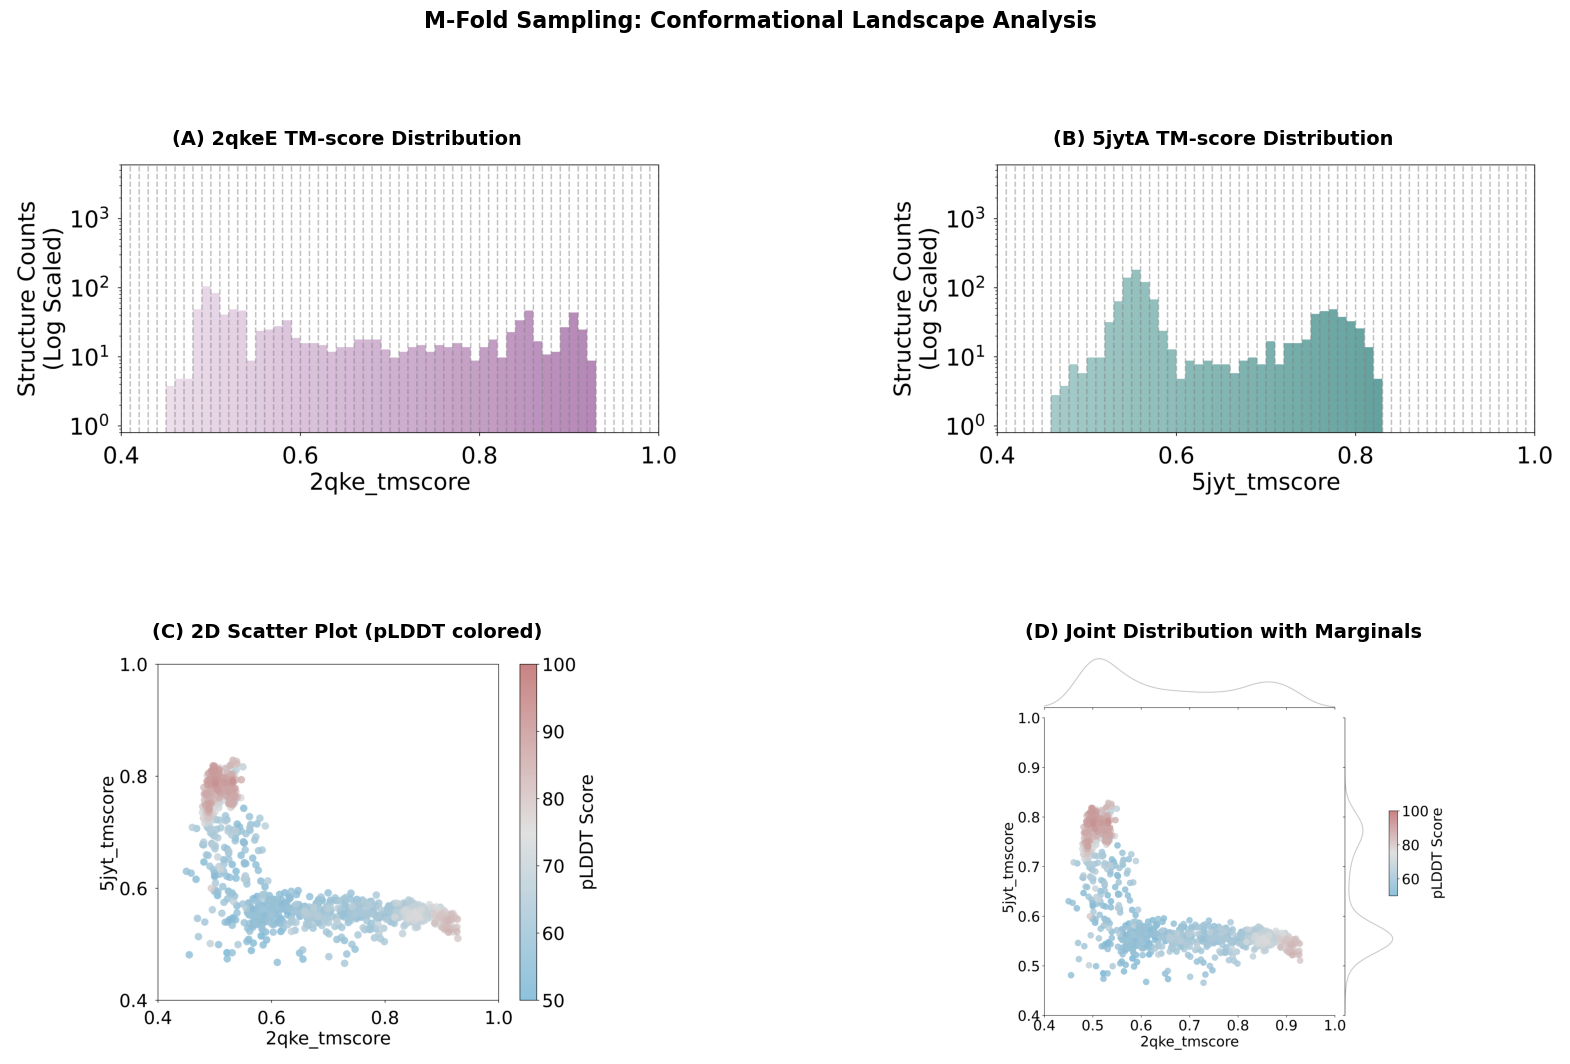


📋 Individual plots:
  - 2qke_tmscore_1d_distribution.png
  - 2qke_tmscore_5jyt_tmscore_joint_plddt.png
  - 2qke_tmscore_5jyt_tmscore_scatter_plddt.png
  - 5jyt_tmscore_1d_distribution.png
  - combined_mfold_analysis.png


In [14]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

# Find all generated plots
plot_files = sorted(list(output_dir.glob("*.png")))

print(f"\n📊 Generated {len(plot_files)} M-fold sampling plots")
print("\nCombining plots into a single canvas...\n")

# Create a combined figure
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# Define plot order and titles
plot_mapping = {
    '2qke_tmscore_1d_distribution.png': (0, 0, '(A) 2qkeE TM-score Distribution'),
    '5jyt_tmscore_1d_distribution.png': (0, 1, '(B) 5jytA TM-score Distribution'),
    '2qke_tmscore_5jyt_tmscore_scatter_plddt.png': (1, 0, '(C) 2D Scatter Plot (pLDDT colored)'),
    '2qke_tmscore_5jyt_tmscore_joint_plddt.png': (1, 1, '(D) Joint Distribution with Marginals')
}

for plot_file in plot_files:
    if plot_file.name in plot_mapping:
        row, col, title = plot_mapping[plot_file.name]
        ax = fig.add_subplot(gs[row, col])
        
        img = mpimg.imread(str(plot_file))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

plt.suptitle('M-Fold Sampling: Conformational Landscape Analysis', 
             fontsize=16, fontweight='bold', y=0.98)

# Save combined figure
combined_path = output_dir / 'combined_mfold_analysis.png'
plt.savefig(combined_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Saved combined figure: {combined_path}")
plt.show()

print("\n📋 Individual plots:")
for plot_file in sorted(plot_files):
    print(f"  - {plot_file.name}")

---

## Stage 2: Sequence Voting

### What is Sequence Voting?

Sequence voting identifies which sequences from the MSA consistently appear in structures with specific metric values:

1. **Bin structures** by metric values (e.g., TM-score bins)
2. **Count occurrences** of each sequence in each bin
3. **Identify top sequences** that are enriched in target bins
4. **Select sequences** for downstream analysis

### Why voting?

- **Signal amplification**: Sequences appearing frequently are more likely to be functionally important
- **Noise reduction**: Random sequences will have low, uniform occurrence
- **State-specific selection**: Different bins capture different conformational states

In [15]:
# Setup voting directories
voting_dir = base_dir / "02_voting"
voting_dir.mkdir(exist_ok=True)

m_fold_sampling_dir = base_dir / "01_m_fold_sampling"

print("🗳️  Sequence Voting Configuration:")
print(f"  Input: {m_fold_sampling_dir}")
print(f"  Output: {voting_dir}")
print(f"  Metrics: {', '.join(selected_metrics)}")
print(f"  Vote threshold: {config.sequence_voting.vote_threshold}")

🗳️  Sequence Voting Configuration:
  Input: m_fold_sampling_voting/01_m_fold_sampling
  Output: m_fold_sampling_voting/02_voting
  Metrics: 2qke_tmscore, 5jyt_tmscore
  Vote threshold: 0.15


### Run Voting for Each Metric

In [16]:
results_files = []

for i, criterion_name in enumerate(selected_metrics):
    print(f"\n🗳️  Processing voting for: {criterion_name}")
    
    # Create criterion-specific output directory
    criterion_output_dir = voting_dir / criterion_name
    criterion_output_dir.mkdir(exist_ok=True)
    
    # Create voting runner
    voting_runner = SequenceVotingRunner(
        sampling_dir=m_fold_sampling_dir,
        source_msa=config.general.source_a3m,
        config_path=config.general.config_file,
        output_dir=criterion_output_dir,
        num_bins=config.general.num_bins,
        max_workers=config.slurm.max_workers,
        vote_threshold=config.sequence_voting.vote_threshold,
        min_value=config.sequence_voting.vote_min_value,
        max_value=config.sequence_voting.vote_max_value,
        use_focused_bins=config.sequence_voting.use_focused_bins,
        precomputed_metrics=base_dir / "01_m_fold_sampling/csv",
        plddt_threshold=config.m_fold_sampling.m_fold_plddt_threshold,
        filter_criterion=criterion_name
    )
    
    # Run voting
    results_file = voting_runner.run()
    
    if results_file:
        results_files.append((criterion_name, results_file))
        print(f"  ✅ Results saved to: {results_file}")
        
        # Create plotter
        colors = config.general.metric1_color if i == 0 else config.general.metric2_color
        
        plotter = SequenceVotingPlotter(
            results_file=results_file,
            output_dir=criterion_output_dir,
            initial_color=colors[0],
            end_color=colors[1],
            figsize=config.sequence_voting.vote_figsize,
            y_min=config.sequence_voting.vote_y_min,
            y_max=config.sequence_voting.vote_y_max,
            x_ticks=config.sequence_voting.vote_x_ticks,
            num_bins=config.general.num_bins,
        )
        
        # Generate plots
        plotter.plot()
        print(f"  ✅ Plots generated")
    else:
        print(f"  ❌ Voting failed for {criterion_name}")

print(f"\n✅ Voting completed for {len(results_files)} metrics")

2026-06-15 17:03:52,965 - af_claseq.af_claseq.m_fold_sampling_voting.sequence_voting - INFO - Starting sequence voting analysis for criterion: 2qke_tmscore


2026-06-15 17:03:52,986 - af_claseq.af_claseq.m_fold_sampling_voting.sequence_voting - INFO - Found existing results file, skipping computation



🗳️  Processing voting for: 2qke_tmscore
  ✅ Results saved to: m_fold_sampling_voting/02_voting/2qke_tmscore/voting_results.csv


2026-06-15 17:03:55,384 - af_claseq.af_claseq.m_fold_sampling_voting.sequence_voting - INFO - Saved plots: m_fold_sampling_voting/02_voting/2qke_tmscore/sequence_voting_distribution.png, m_fold_sampling_voting/02_voting/2qke_tmscore/sequence_voting_distribution.pdf, m_fold_sampling_voting/02_voting/2qke_tmscore/sequence_voting_distribution.svg


2026-06-15 17:03:55,390 - af_claseq.af_claseq.m_fold_sampling_voting.sequence_voting - INFO - Created distribution plot: m_fold_sampling_voting/02_voting/2qke_tmscore/sequence_voting_distribution


...

2026-06-15 17:03:55,482 - af_claseq.af_claseq.m_fold_sampling_voting.sequence_voting - INFO - Found existing results file, skipping computation


  ✅ Plots generated

🗳️  Processing voting for: 5jyt_tmscore
  ✅ Results saved to: m_fold_sampling_voting/02_voting/5jyt_tmscore/voting_results.csv


2026-06-15 17:03:57,794 - af_claseq.af_claseq.m_fold_sampling_voting.sequence_voting - INFO - Saved plots: m_fold_sampling_voting/02_voting/5jyt_tmscore/sequence_voting_distribution.png, m_fold_sampling_voting/02_voting/5jyt_tmscore/sequence_voting_distribution.pdf, m_fold_sampling_voting/02_voting/5jyt_tmscore/sequence_voting_distribution.svg


2026-06-15 17:03:57,801 - af_claseq.af_claseq.m_fold_sampling_voting.sequence_voting - INFO - Created distribution plot: m_fold_sampling_voting/02_voting/5jyt_tmscore/sequence_voting_distribution


  ✅ Plots generated

✅ Voting completed for 2 metrics


### Examine Voting Results

In [17]:
# Load and display voting results for first metric
if results_files:
    metric_name, results_file = results_files[0]
    voting_df = pd.read_csv(results_file)
    
    print(f"📊 Voting Results for {metric_name}:")
    print(f"  Total bins with sequences: {voting_df['Bin_Assignment'].nunique()}")
    print(f"  Total unique sequences voted: {len(voting_df)}")
    
    print(f"\n🏆 Top 10 sequences by vote count:")
    display(voting_df.head(10))
    
    # Show distribution across bins
    bin_counts = voting_df.groupby('Bin_Assignment')['Vote_Count'].sum().sort_values(ascending=False)
    print(f"\n📊 Top 5 bins by total votes:")
    print(bin_counts.head())

📊 Voting Results for 2qke_tmscore:
  Total bins with sequences: 13
  Total unique sequences voted: 127

🏆 Top 10 sequences by vote count:


,Sequence_Header,Bin_Assignment,Vote_Count,Total_Votes
0,SRR6267142_1309473,9,5,32
1,UPI000EAFD4D2,11,5,32
2,UniRef100_A0A173MHF4,10,6,32
3,SRR6185437_13878594,10,5,32
4,SRR5262245_9563575,11,6,32
5,UniRef100_A0A1I7LTT2,11,7,32
6,A0A1G1IKG5,46,5,32
7,A0A822IKC8,11,5,32
8,SRR5436190_12106532,10,5,32
9,A0A366L8T7,11,6,32



📊 Top 5 bins by total votes:
Bin_Assignment
10    398
11    177
9      54
14     33
46     30
Name: Vote_Count, dtype: int64


### Display Voting Plots


📊 Combining voting distribution plots...



✅ Saved combined voting figure: m_fold_sampling_voting/02_voting/combined_voting_distribution.png


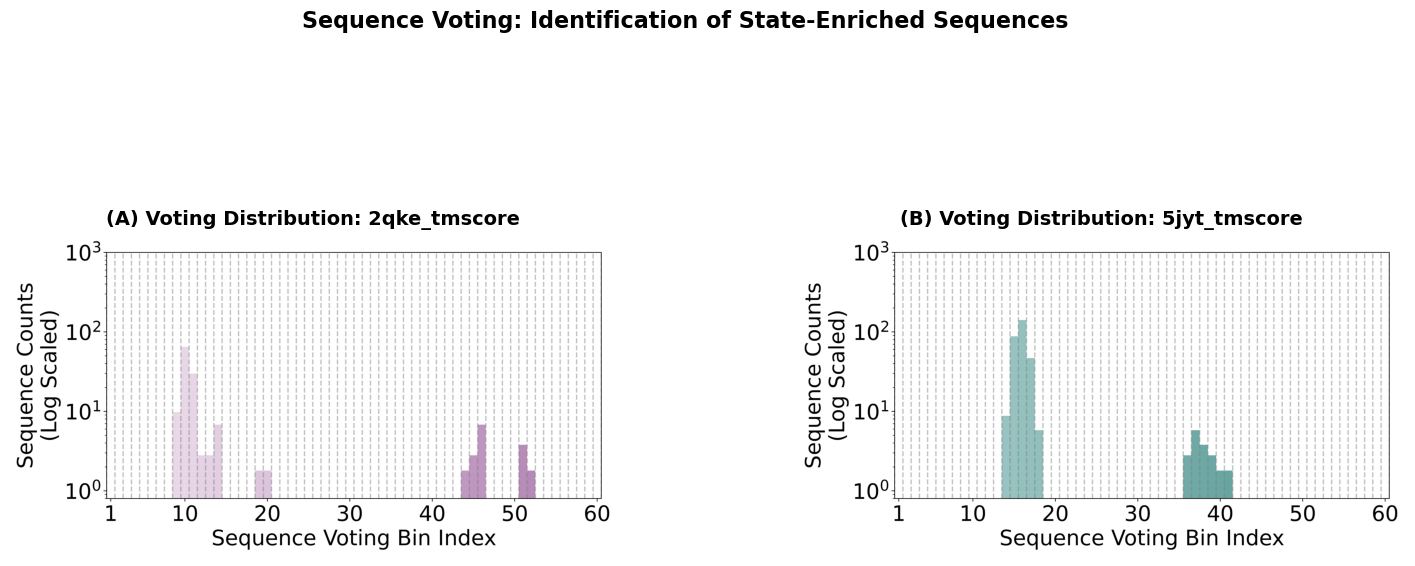


📋 Individual voting plots:
  - 2qke_tmscore: sequence_voting_distribution.png
  - 5jyt_tmscore: sequence_voting_distribution.png


In [18]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec

# Display voting plots in combined canvas
print("\n📊 Combining voting distribution plots...\n")

fig = plt.figure(figsize=(18, 8))
gs = GridSpec(1, 2, figure=fig, hspace=0.2, wspace=0.3)

plot_data = []
for idx, (metric_name, _) in enumerate(results_files):
    criterion_output_dir = voting_dir / metric_name
    plot_file = criterion_output_dir / "sequence_voting_distribution.png"
    
    if plot_file.exists():
        plot_data.append((idx, metric_name, plot_file))

for idx, metric_name, plot_file in plot_data:
    ax = fig.add_subplot(gs[0, idx])
    img = mpimg.imread(str(plot_file))
    ax.imshow(img)
    ax.axis('off')
    
    title = f"({'AB'[idx]}) Voting Distribution: {metric_name}"
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Sequence Voting: Identification of State-Enriched Sequences', 
             fontsize=16, fontweight='bold', y=0.98)

# Save combined figure
combined_voting_path = voting_dir / 'combined_voting_distribution.png'
plt.savefig(combined_voting_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Saved combined voting figure: {combined_voting_path}")
plt.show()

print("\n📋 Individual voting plots:")
for _, metric_name, plot_file in plot_data:
    print(f"  - {metric_name}: {plot_file.name}")

---

## Stage 3: Sequence Recompilation & Prediction

### What is Recompilation?

Based on voting results, we select sequences from specific bins (representing desired conformational states) and:

1. **Extract top-voted sequences** from target bins
2. **Compile new MSAs** containing these sequences
3. **Predict structures** with higher sampling (more models, more seeds)
4. **Compare to reference structures**

This stage uses higher prediction parameters to get better quality structures for the selected sequences.

In [19]:
# Setup recompilation directory
base_output_dir = base_dir / "03_recompile"
base_output_dir.mkdir(exist_ok=True)

print("🔧 Recompilation Configuration:")
print(f"  Output: {base_output_dir}")
print(f"  Prediction models: {config.recompile_predict.prediction_num_model}")
print(f"  Prediction seeds: {config.recompile_predict.prediction_num_seed}")

🔧 Recompilation Configuration:
  Output: m_fold_sampling_voting/03_recompile
  Prediction models: 5
  Prediction seeds: 8


### Process Each Metric

In [20]:
for i, criterion_name in enumerate(selected_metrics):
    print(f"\n🔧 Processing recompilation for: {criterion_name}")
    
    # Create criterion-specific output directory
    criterion_output_dir = base_output_dir / criterion_name
    criterion_output_dir.mkdir(exist_ok=True)

    # ── Pre-computed shortcut ──
    # If recompiled predictions already exist (e.g. extracted from the
    # pre-computed tarball), skip recompilation + ColabFold so the
    # notebook runs end-to-end on CPU. Mirrors the Stage 01 sampling-skip.
    existing_preds = list((criterion_output_dir / "prediction").glob("bin_*/*.pdb"))
    if existing_preds:
        print(f"  ✅ Found {len(existing_preds)} existing predictions — skipping recompile + ColabFold for {criterion_name}")
        continue
    
    # Get voting results
    voting_results = base_dir / f"02_voting/{criterion_name}/voting_results.csv"
    raw_votes_json = base_dir / f"02_voting/{criterion_name}/raw_sequence_votes.json"
    
    if not voting_results.exists():
        print(f"  ❌ Voting results not found: {voting_results}")
        continue
    
    # Determine bin numbers
    if criterion_name == config.recompile_predict.metric_name_1:
        bin_numbers = config.recompile_predict.bin_numbers_1
    elif criterion_name == config.recompile_predict.metric_name_2:
        bin_numbers = config.recompile_predict.bin_numbers_2
    else:
        bin_numbers = config.recompile_predict.bin_numbers_1
    
    print(f"  Target bins: {bin_numbers}")
    
    # Create sequence recompiler
    colors = config.general.metric1_color if i == 0 else config.general.metric2_color
    
    recompiler = SequenceRecompiler(
        output_dir=criterion_output_dir,
        source_msa=config.general.source_a3m,
        voting_results=voting_results,
        bin_numbers=bin_numbers,
        num_total_bins=config.general.num_bins,
        initial_color=colors[0],
        combine_bins=config.recompile_predict.combine_bins,
        raw_votes_json=raw_votes_json if raw_votes_json.exists() else None,
        logger=logger
    )
    
    # Recompile sequences (creates A3M files for predictions and controls)
    print(f"  📝 Recompiling sequences...")
    recompiler.recompile_sequences()
    
    # Now run ColabFold predictions with higher quality settings
    print(f"  🔄 Running structure predictions...")
    print(f"     Settings: {config.recompile_predict.prediction_num_model} models, "
          f"{config.recompile_predict.prediction_num_seed} seeds")
    
    # Create a new GPU executor with higher quality settings
    prediction_executor = DirectGPUExecutor(
        conda_env_path=config.slurm.conda_env_path,
        gpu_ids=GPU_IDS,
        num_models=config.recompile_predict.prediction_num_model,
        num_seeds=config.recompile_predict.prediction_num_seed,
        num_recycle=3,
        random_seed=config.general.random_seed
    )
    
    # Find all folders that need predictions
    # SequenceRecompiler creates: prediction/bin_XX/ and control_prediction/bin_XX/
    folders_to_predict = []
    job_ids = []
    
    # Add bin folders from prediction/ directory
    prediction_dir = criterion_output_dir / "prediction"
    if prediction_dir.exists():
        for bin_num in bin_numbers:
            bin_folder = prediction_dir / f"bin_{bin_num}"
            if bin_folder.exists():
                folders_to_predict.append(str(bin_folder))
                job_ids.append(f"{criterion_name}_bin_{bin_num}")
    
    # Add control folders from control_prediction/ directory
    control_prediction_dir = criterion_output_dir / "control_prediction"
    if control_prediction_dir.exists():
        for bin_num in bin_numbers:
            control_bin_folder = control_prediction_dir / f"bin_{bin_num}"
            if control_bin_folder.exists():
                folders_to_predict.append(str(control_bin_folder))
                job_ids.append(f"{criterion_name}_control_bin_{bin_num}")
    
    if folders_to_predict:
        print(f"  📁 Found {len(folders_to_predict)} folders to predict:")
        for folder_path in folders_to_predict:
            folder_name = Path(folder_path).name
            parent_name = Path(folder_path).parent.name
            a3m_count = len(list(Path(folder_path).glob("*.a3m")))
            print(f"     - {parent_name}/{folder_name}: {a3m_count} sequences")
        
        # Run predictions in parallel across GPUs
        prediction_executor.process_folders_concurrently(
            folders=folders_to_predict,
            job_ids=job_ids,
            max_workers=MAX_WORKERS
        )
        
        print(f"  ✅ Predictions completed for {criterion_name}")
    else:
        print(f"  ⚠️  No folders found to predict for {criterion_name}")

print("\n✅ Recompilation and prediction stage completed")


🔧 Processing recompilation for: 2qke_tmscore
  ✅ Found 69 existing predictions — skipping recompile + ColabFold for 2qke_tmscore

🔧 Processing recompilation for: 5jyt_tmscore
  ✅ Found 40 existing predictions — skipping recompile + ColabFold for 5jyt_tmscore

✅ Recompilation and prediction stage completed


---

## Stage 4: Pure Sequence Plotting & Analysis

### Final Visualization

Compare the structures predicted from selected sequences against:
- Reference structures (2qkeE, 5jytA)
- Control predictions (random sequences)
- M-fold sampling results

In [21]:
# Setup plotting directory
plot_base_dir = base_dir / "04_plots"
plot_base_dir.mkdir(exist_ok=True)

print("📊 Pure Sequence Plotting Configuration:")
print(f"  Output: {plot_base_dir}")
print(f"  pLDDT threshold: {config.pure_sequence_plotting.plddt_threshold}")

📊 Pure Sequence Plotting Configuration:
  Output: m_fold_sampling_voting/04_plots
  pLDDT threshold: 0


In [22]:
for i, criterion_name in enumerate(selected_metrics):
    print(f"\n📊 Generating plots for: {criterion_name}")
    
    # Create criterion-specific output directory
    criterion_output_dir = plot_base_dir / criterion_name
    criterion_output_dir.mkdir(exist_ok=True)
    
    # Get recompile directory
    recompile_dir = base_dir / f"03_recompile/{criterion_name}"
    
    if not recompile_dir.exists():
        print(f"  ❌ Recompile directory not found: {recompile_dir}")
        continue
    
    # Create plotting configuration
    plot_config = {
        'base_dir': recompile_dir,
        'output_dir': criterion_output_dir,
        'config_file': config.general.config_file,
        'color_prediction': config.general.metric1_color[0] if i == 0 else config.general.metric2_color[0],
        'color_control': config.general.metric1_color[1] if i == 0 else config.general.metric2_color[1],
        'metric1_min': config.pure_sequence_plotting.metric1_min,
        'metric1_max': config.pure_sequence_plotting.metric1_max,
        'metric2_min': config.pure_sequence_plotting.metric2_min,
        'metric2_max': config.pure_sequence_plotting.metric2_max,
        'metric1_ticks': config.pure_sequence_plotting.metric1_ticks,
        'metric2_ticks': config.pure_sequence_plotting.metric2_ticks,
        'plddt_threshold': config.pure_sequence_plotting.plddt_threshold,
        'figsize': config.pure_sequence_plotting.figsize,
        'dpi': config.pure_sequence_plotting.dpi,
        'max_workers': config.slurm.max_workers
    }
    
    # Create and run plotter
    plotter = PureSequencePlotter(
        config=create_pure_seq_plot_config_from_dict(plot_config),
        logger=logger
    )
    
    result = plotter.run()
    
    if result:
        print(f"  ✅ Plots generated for {criterion_name}")
    else:
        print(f"  ❌ Plotting failed for {criterion_name}")

print("\n✅ Pure sequence plotting completed")


📊 Generating plots for: 2qke_tmscore


2026-06-15 17:04:07,015 - af_claseq - INFO - Starting pure sequence plotting


2026-06-15 17:04:07,044 - af_claseq - INFO - Calculating metrics for 2qke_tmscore, 5jyt_tmscore


2026-06-15 17:04:07,070 - af_claseq.af_claseq.utils.structure_analysis - INFO - Processing m_fold_sampling_voting/03_recompile/2qke_tmscore/prediction/bin_51_52


2026-06-15 17:04:07,115 - af_claseq.af_claseq.utils.structure_analysis - INFO - Found 69 PDB files


...

2026-06-15 17:06:57,396 - af_claseq.af_claseq.utils.structure_analysis - INFO - Successfully analyzed 40 structures in parallel


2026-06-15 17:06:59,159 - af_claseq - INFO - Saved plots: m_fold_sampling_voting/04_plots/5jyt_tmscore/bin_37_38_39_40_41/prediction/2qke_tmscore_5jyt_tmscore_scatter_plddt.png, m_fold_sampling_voting/04_plots/5jyt_tmscore/bin_37_38_39_40_41/prediction/2qke_tmscore_5jyt_tmscore_scatter_plddt.pdf, m_fold_sampling_voting/04_plots/5jyt_tmscore/bin_37_38_39_40_41/prediction/2qke_tmscore_5jyt_tmscore_scatter_plddt.svg


2026-06-15 17:07:00,961 - af_claseq - INFO - Saved plots: m_fold_sampling_voting/04_plots/5jyt_tmscore/bin_37_38_39_40_41/control_prediction/2qke_tmscore_5jyt_tmscore_scatter_plddt.png, m_fold_sampling_voting/04_plots/5jyt_tmscore/bin_37_38_39_40_41/control_prediction/2qke_tmscore_5jyt_tmscore_scatter_plddt.pdf, m_fold_sampling_voting/04_plots/5jyt_tmscore/bin_37_38_39_40_41/control_prediction/2qke_tmscore_5jyt_tmscore_scatter_plddt.svg


2026-06-15 17:07:01,022 - af_claseq - INFO - Pure sequence plotting completed successfully


  ✅ Plots generated for 5jyt_tmscore

✅ Pure sequence plotting completed


### Display Final Plots


📊 Combining final prediction plots into labeled canvas...



✅ Saved combined final figure: m_fold_sampling_voting/04_plots/combined_final_predictions.png


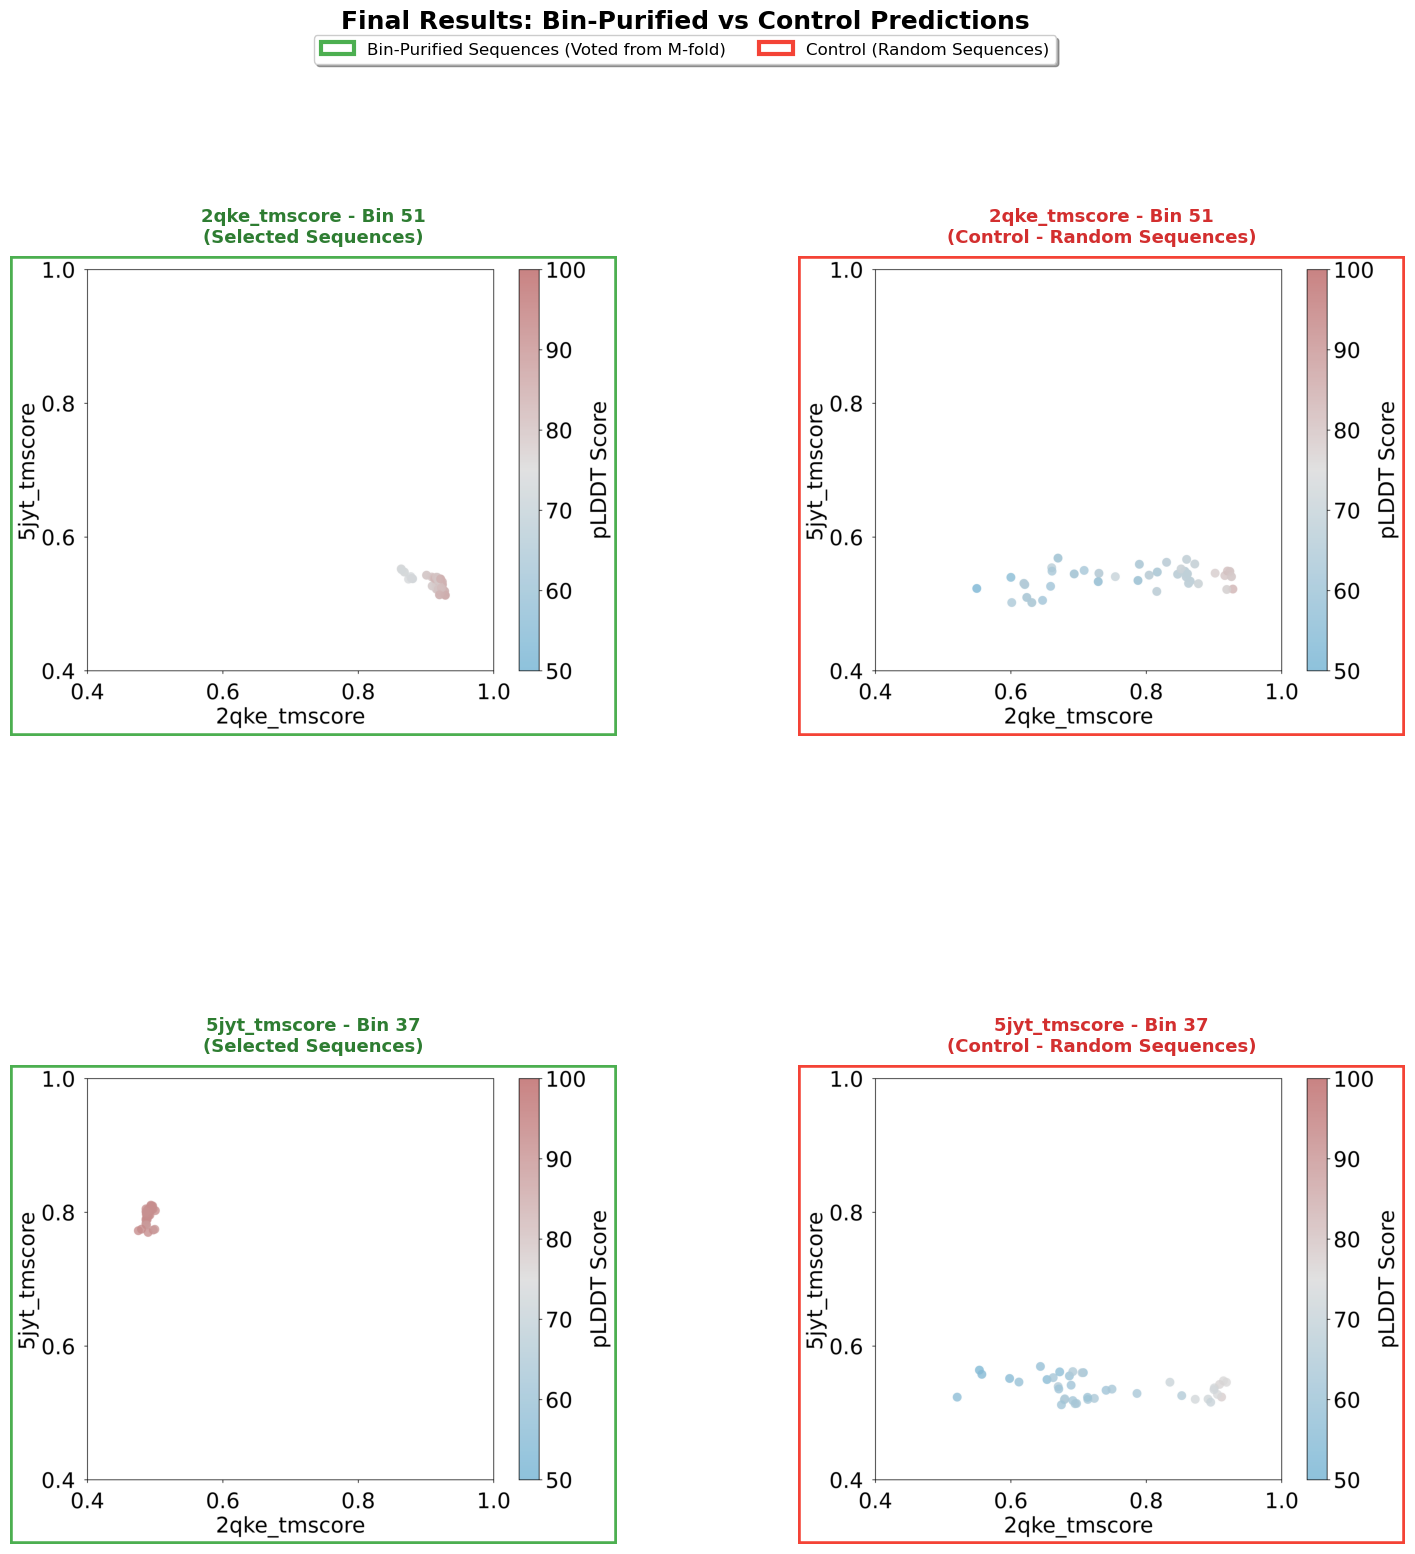


📋 Displayed 4 prediction plots:
  - Bin-Purified Sequences    | 2qke_tmscore    | Bin 51
  - Control (Random)          | 2qke_tmscore    | Bin 51
  - Bin-Purified Sequences    | 5jyt_tmscore    | Bin 37
  - Control (Random)          | 5jyt_tmscore    | Bin 37

🎯 Interpretation Guide:
  • GREEN borders: Sequences enriched in specific conformational state (from voting)
  • RED borders: Random control sequences for comparison
  • Compare the clustering patterns between purified and control predictions
  • Successful enrichment shows tighter clustering in target conformational region


In [23]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

print("\n📊 Combining final prediction plots into labeled canvas...\n")

# Collect all final plots
all_plots = []
for metric_name in selected_metrics:
    criterion_output_dir = plot_base_dir / metric_name
    
    # Find bin folders
    for bin_folder in sorted(criterion_output_dir.glob("bin_*")):
        bin_num = bin_folder.name.split('_')[1]
        
        # Prediction plot
        pred_plot = bin_folder / "prediction" / "2qke_tmscore_5jyt_tmscore_scatter_plddt.png"
        if pred_plot.exists():
            all_plots.append({
                'path': pred_plot,
                'metric': metric_name,
                'bin': bin_num,
                'type': 'Bin-Purified Sequences',
                'label': f"{metric_name} - Bin {bin_num}\n(Selected Sequences)"
            })
        
        # Control plot
        ctrl_plot = bin_folder / "control_prediction" / "2qke_tmscore_5jyt_tmscore_scatter_plddt.png"
        if ctrl_plot.exists():
            all_plots.append({
                'path': ctrl_plot,
                'metric': metric_name,
                'bin': bin_num,
                'type': 'Control (Random)',
                'label': f"{metric_name} - Bin {bin_num}\n(Control - Random Sequences)"
            })

if not all_plots:
    print("⚠️  No final plots found. Make sure Stage 3 predictions have completed.")
else:
    # Create combined figure
    n_plots = len(all_plots)
    n_cols = 2
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig = plt.figure(figsize=(18, 9 * n_rows))
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.4, wspace=0.3)
    
    for idx, plot_info in enumerate(all_plots):
        row = idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        
        img = mpimg.imread(str(plot_info['path']))
        ax.imshow(img)
        ax.axis('off')
        
        # Add title with color coding
        title_color = '#2E7D32' if 'Bin-Purified' in plot_info['type'] else '#D32F2F'
        ax.set_title(plot_info['label'], fontsize=13, fontweight='bold', 
                    pad=10, color=title_color)
        
        # Add border
        border_color = '#4CAF50' if 'Bin-Purified' in plot_info['type'] else '#F44336'
        rect = Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                        fill=False, edgecolor=border_color, linewidth=4)
        ax.add_patch(rect)
    
    plt.suptitle('Final Results: Bin-Purified vs Control Predictions', 
                 fontsize=18, fontweight='bold', y=0.99)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='white', edgecolor='#4CAF50', linewidth=3, 
              label='Bin-Purified Sequences (Voted from M-fold)'),
        Patch(facecolor='white', edgecolor='#F44336', linewidth=3, 
              label='Control (Random Sequences)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, 0.98), ncol=2, fontsize=12, 
              frameon=True, fancybox=True, shadow=True)
    
    # Save combined figure
    combined_final_path = plot_base_dir / 'combined_final_predictions.png'
    plt.savefig(combined_final_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Saved combined final figure: {combined_final_path}")
    plt.show()
    
    print(f"\n📋 Displayed {len(all_plots)} prediction plots:")
    for plot_info in all_plots:
        print(f"  - {plot_info['type']:25s} | {plot_info['metric']:15s} | Bin {plot_info['bin']}")
    
    print("\n🎯 Interpretation Guide:")
    print("  • GREEN borders: Sequences enriched in specific conformational state (from voting)")
    print("  • RED borders: Random control sequences for comparison")
    print("  • Compare the clustering patterns between purified and control predictions")
    print("  • Successful enrichment shows tighter clustering in target conformational region")

---

## Summary & Results

### Pipeline Completion Summary

In [24]:
print("="*70)
print("🎉 AF-CLASEQ PIPELINE COMPLETED SUCCESSFULLY")
print("="*70)

print("\n📂 Output Directory Structure:")
print(f"  {base_dir}/")
print(f"    ├── 01_m_fold_sampling/  - Sampling results and analysis")
print(f"    ├── 02_voting/           - Sequence voting results")
print(f"    ├── 03_recompile/        - Selected sequences and predictions")
print(f"    ├── 04_plots/            - Final comparative plots")
print(f"    └── logs/                - Pipeline logs")

# Count results
sampling_dirs = list((base_dir / "01_m_fold_sampling/round_1/01_sampling").glob("sampling_*"))
voting_csvs = list((base_dir / "02_voting").glob("*/voting_results.csv"))

print(f"\n📊 Results Summary:")
print(f"  Sampling rounds: {len(sampling_dirs)}")
print(f"  Metrics analyzed: {len(selected_metrics)}")
print(f"  Voting results: {len(voting_csvs)} files")

print("\n✅ All stages completed successfully!")
print("\n💡 Next Steps:")
print("  1. Review the plots to understand conformational landscape")
print("  2. Examine voting results to identify important sequences")
print("  3. Analyze final predictions against reference structures")
print("  4. Use selected sequences for downstream experiments")

🎉 AF-CLASEQ PIPELINE COMPLETED SUCCESSFULLY

📂 Output Directory Structure:
  m_fold_sampling_voting/
    ├── 01_m_fold_sampling/  - Sampling results and analysis
    ├── 02_voting/           - Sequence voting results
    ├── 03_recompile/        - Selected sequences and predictions
    ├── 04_plots/            - Final comparative plots
    └── logs/                - Pipeline logs

📊 Results Summary:
  Sampling rounds: 33
  Metrics analyzed: 2
  Voting results: 2 files

✅ All stages completed successfully!

💡 Next Steps:
  1. Review the plots to understand conformational landscape
  2. Examine voting results to identify important sequences
  3. Analyze final predictions against reference structures
  4. Use selected sequences for downstream experiments


---

## Biological Interpretation

### Understanding the Results

**KaiB Conformational States:**
- **High 2qke_tmscore**: Structures similar to tetramer fold-switched state
- **High 5jyt_tmscore**: Structures similar to monomer ground state

**Key Questions to Ask:**
1. Did we sample both conformational states?
2. Which sequences are enriched in each state?
3. Are there intermediate conformations?
4. How do the voted sequences compare to random controls?

### Applying to Your Protein

To adapt this pipeline for your own protein:

1. **Prepare input MSA** (A3M format)
2. **Define reference structures** for metrics
3. **Update configuration file** with:
   - Protein name and paths
   - Reference structures
   - Sampling parameters
   - Bin selections
4. **Run pipeline** with adjusted parameters
5. **Iterate** based on results

---

### Citation

If you use this pipeline, please cite:
- AF-ClaSeq: [Your publication]
- ColabFold: Mirdita et al., Nature Methods 2022
- AlphaFold2: Jumper et al., Nature 2021